# Preditor de Lutas UFC com Machine Learning

**Disciplina:** Linguagem de Programação Python Aplicada a Machine Learning

---

## 1. Definição do Problema

**Objetivo:** Quero tenta prever qual lutador vencerá um confronto no UFC, fornecendo a **probabilidade de vitória** para cada atleta.

**Tipo de problema:** Classificação binária
- Classe 1 → Fighter 1 vence
- Classe 0 → Fighter 2 vence

**Estratégia:** Para cada luta, cruzamos as estatísticas de carreira de cada lutador e calculamos a **diferença** entre os dois (features diferenciais). O modelo aprende quais diferenças estatísticas são mais determinantes para o resultado.

**Datasets:**
- `DATA/ufc_fighters_final.csv` — perfil e stats de carreira (4.455 lutadores)
- `DATA/ufc_gold_dataset_final.csv` — histórico de lutas com resultados (8.551 lutas)

---
## 📋 Guia de Revisão — Para Professores e Avaliadores

Este notebook aplica Machine Learning para prever resultados de lutas de MMA no UFC.  
Está organizado em seções numeradas para facilitar a leitura e revisão.  
O mapa abaixo indica o conteúdo e os pontos técnicos de cada etapa:

| Seção | Título | Pontos para revisar |
|:---:|---|---|
| 2 | Imports e Configuração | Bibliotecas utilizadas (sklearn, pandas, matplotlib) |
| 3 | Carregamento dos Dados | Leitura dos dois CSVs; shape dos DataFrames |
| 3.1 | Entendendo os Dados | Dicionário completo das colunas dos datasets |
| 4 | Preparação dos Dados | Tratamento de valores nulos; parsing de strings |
| 5 | Engenharia de Features | Criação das 16 features diferenciais (F1 − F2) |
| 6 | Treino / Validação / Teste | Split 70/15/15; `stratify`; `StandardScaler` sem data leakage |
| 7 | Implementação dos Modelos | 3 algoritmos + tuning via `GridSearchCV`/`RandomizedSearchCV` |
| 8 | Avaliação e Comparação | Acurácia, AUC-ROC, Curvas ROC, Matrizes de Confusão |
| 9 | Discussão dos Resultados | Análise crítica; trade-offs entre modelos |
| 10 | Preditor de Lutas | Interface interativa com glossário acessível |
| 11 | Conclusão | Resumo do pipeline e trabalhos futuros |

---

### ✅ Boas práticas implementadas (pontos de destaque)

- **Sem data leakage:** o `StandardScaler` é ajustado (`fit`) apenas no conjunto de treino e aplicado (`transform`) nos demais conjuntos.
- **Teste usado uma única vez:** o conjunto de teste é tocado somente na avaliação final (Seção 8.1), garantindo estimativa não-enviesada.
- **Stratified split:** a proporção de vitórias de F1/F2 é preservada em todos os conjuntos via `stratify=y`.
- **Features diferenciais:** calcular F1 − F2 elimina o viés posicional (a atribuição de quem é F1 é arbitrária nos dados históricos).
- **Busca de hiperparâmetros:** `GridSearchCV` (espaço pequeno) e `RandomizedSearchCV` (espaço grande) com `cv=5`.

---

### ⚠️ Limitações conhecidas (sugestão de discussão)

- Acurácia de **~65–70%** é esperada: lutas de MMA têm alta imprevisibilidade por natureza.
- Estatísticas são **médias de carreira** — não capturam evolução temporal nem forma recente do atleta.
- O modelo não considera **compatibilidade de estilos** (ex.: wrestlers vs. especialistas em striking).
- Sem dados de **camp de treinamento**, lesões ou motivação do atleta.


---
## 2. Imports e Configuração

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
SEED = 42
print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
## 3. Carregamento dos Dados

In [53]:
fighters = pd.read_csv('DATA/ufc_fighters_final.csv')
fights   = pd.read_csv('DATA/ufc_gold_dataset_final.csv')

print(f'Lutadores: {fighters.shape[0]:,} x {fighters.shape[1]}')
print(f'Lutas:     {fights.shape[0]:,} x {fights.shape[1]}')
fighters.head(3)

Lutadores: 4,455 x 18
Lutas:     8,551 x 37


,Fighter_Name,Height,Weight,Reach,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Fighter_URL
0,Tom Aaron,NaN,155 lbs.,NaN,NaN,1978-07-13,5,3,0,0.00,0%,0.00,0%,0.0,0%,0%,0.0,http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny Abbadi,"5' 11""",155 lbs.,NaN,Orthodox,1983-07-03,4,6,0,3.29,38%,4.41,57%,0.0,0%,77%,0.0,http://ufcstats.com/fighter-details/15df64c02b...
2,Nariman Abbasov,"5' 8""",155 lbs.,"66.0""",Orthodox,1994-02-01,28,4,0,3.00,20%,5.67,46%,0.0,0%,66%,0.0,http://ufcstats.com/fighter-details/59a9d6dac6...


In [54]:
fights.head(3)

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,F1_KD,F2_KD,F1_Sig_Landed,F1_Sig_Att,F2_Sig_Landed,F2_Sig_Att,F1_TD_Landed,F2_TD_Landed,F1_TD_Att,F2_TD_Att,F1_Sub_Att,F2_Sub_Att,F1_Ctrl_Sec,F2_Ctrl_Sec,F1_Head,F2_Head,F1_Body,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date
0,http://ufcstats.com/fight-details/4acab67848e7...,Scott Morris,Sean Daugherty,Scott Morris,Open Weight Bout,Submission,1,0:20,20,No Time Limit,0,0,1,1,0,4,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1994-03-11
1,http://ufcstats.com/fight-details/4b9ae533ccb3...,Patrick Smith,Ray Wizard,Patrick Smith,Open Weight Bout,Submission,1,0:58,58,No Time Limit,0,0,1,1,1,1,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,1,0,0,0,1994-03-11
2,http://ufcstats.com/fight-details/00835554f95f...,Royce Gracie,Patrick Smith,Royce Gracie,UFC 2 Tournament Title Bout,KO/TKO,1,1:17,77,No Time Limit,0,0,4,4,1,2,1,0,2,0,0,0,0,0,3,0,0,1,1,0,0,0,1,1,3,0,1994-03-11


---
## 3.1 Entendendo os Dados — Guia Completo dos Datasets

### O que é o UFC / MMA?

O **Ultimate Fighting Championship (UFC)** é a maior organização de **MMA (Mixed Martial Arts — Artes Marciais Mistas)** do mundo.  
Os atletas competem em **categorias de peso** e podem vencer de quatro formas:

| Forma de Vitória | Código | O que significa |
|---|---|---|
| Nocaute / Nocaute Técnico | `KO/TKO` | Golpe que derruba/incapacita o adversário; o árbitro para a luta |
| Finalização | `Submission` | Chave de braço, estrangulamento — adversário desiste ("bate") |
| Decisão dos Juízes | `Decision` | Os 3 juízes da beira do ringue pontuam os rounds e elegem o vencedor |
| Empate / Sem Resultado | `Draw / NC` | Raros; pontuação igual ou luta cancelada |

---

### Dataset 1 — `ufc_fighters_final.csv` (4.455 atletas, 18 colunas)

Cada linha representa **um lutador** com suas estatísticas acumuladas de carreira.

| Coluna | Tradução / Significado | Unidade | Observação |
|---|---|---|---|
| `Fighter_Name` | Nome do atleta | — | Chave para cruzar com as lutas |
| `Height_cm` | Altura | cm | Convertido de pés/polegadas |
| `Weight_lbs` | Peso | libras | Reflete a categoria de luta |
| `Reach_cm` | Alcance (envergadura dos braços) | cm | Alcance maior → vantagem no striking à distância |
| `Stance` | Postura de combate | — | *Orthodox* = destro; *Southpaw* = canhoto; *Switch* = ambos |
| `Age` | Idade | anos | Calculado a partir da data de nascimento |
| `Win_Rate` | Taxa de vitórias na carreira | 0–1 (ex: 0.80 = 80%) | Ex.: 28 vitórias em 35 lutas → 0.80 |
| `Total_Fights` | Total de lutas no UFC | nº de lutas | Indica experiência no octógono |
| `SLpM` | **Sig. Strikes Landed per Minute** — golpes significativos **dados** por minuto | golpes/min | Mede poder ofensivo; valores altos → lutador agressivo |
| `Str_Acc_f` | **Strike Accuracy** — precisão dos golpes dados | 0–1 | Ex.: 0.50 = acerta 50% dos golpes tentados |
| `SApM` | **Sig. Strikes Absorbed per Minute** — golpes significativos **recebidos** por minuto | golpes/min | Mede vulnerabilidade; valores baixos → boa defesa |
| `Str_Def_f` | **Strike Defense** — % de golpes do adversário bloqueados/evitados | 0–1 | Ex.: 0.60 = evita 60% dos ataques adversários |
| `TD_Avg` | **Takedown Average** — média de derrubadas aplicadas por luta | derrubadas/luta | Derrubada = jogar o adversário no chão (wrestling) |
| `TD_Acc_f` | **Takedown Accuracy** — % de tentativas de derrubada bem-sucedidas | 0–1 | Ex.: 0.40 = 40% das tentativas convertem em derrubada |
| `TD_Def_f` | **Takedown Defense** — % de tentativas do adversário defendidas | 0–1 | Ex.: 0.80 = defende 80% das tentativas |
| `Sub_Avg` | **Submission Average** — tentativas de finalização por luta | tentativas/luta | Finalização = chave, estrangulamento, etc. |

> **Nota técnica:** `SLpM` e `SApM` juntos formam o "saldo de striking":  
> `Eficiência = SLpM − SApM`. Valor positivo = o lutador **dá mais golpes do que recebe**.

---

### Dataset 2 — `ufc_gold_dataset_final.csv` (8.551 lutas, 37 colunas)

Cada linha representa **uma luta** com informações do evento e resultado.

| Coluna | O que significa |
|---|---|
| `Fighter_1` / `Fighter_2` | Nomes dos dois atletas |
| `Winner` | Nome de quem venceu |
| `Method` | Forma de vitória: `KO/TKO`, `Submission`, `Decision`, `Draw` |
| `Weight_Class` | Categoria de peso (ex.: *Lightweight* = Leve ≤ 70 kg; *Heavyweight* = Pesado ≤ 120 kg) |
| `Date` | Data do evento |
| Demais colunas | Estatísticas detalhadas round-a-round (usadas na limpeza e análise exploratória) |

---

### Como os dois datasets se combinam no modelo?

```
ufc_fighters_final.csv       →  perfil estatístico de cada atleta (médias de carreira)
          +
ufc_gold_dataset_final.csv   →  histórico de confrontos (quem lutou com quem e quem venceu)
          ↓
    Para cada luta:  DIFF_stat = stat(Lutador1) − stat(Lutador2)
          ↓
    O modelo aprende: quais diferenças entre os atletas melhor predizem a vitória?
```

Um `DIFF_SLpM` positivo (ex.: +2.5) indica que o Lutador 1 acerta 2.5 golpes/min a mais — vantagem ofensiva.  
Usar diferenças em vez de valores absolutos elimina o viés de quem é arbitrariamente chamado de "F1" no registro histórico.


---
## 4. Preparação dos Dados

### 4.1 Limpeza do dataset de lutadores

In [55]:
print('=== Valores nulos — Lutadores ===')
print(fighters.isnull().sum().sort_values(ascending=False))

=== Valores nulos — Lutadores ===
Reach           1940
Stance           849
DOB              506
Height           318
Weight            86
Fighter_Name       0
Wins               0
Losses             0
Draws              0
SLpM               0
Str_Acc            0
SApM               0
Str_Def            0
TD_Avg             0
TD_Acc             0
TD_Def             0
Sub_Avg            0
Fighter_URL        0
dtype: int64


In [56]:
def parse_height(h):
    if pd.isna(h) or str(h).strip() == '': return np.nan
    m = re.match(r"(\d+)'\s*(\d+)\"", str(h))
    return round((int(m.group(1))*12 + int(m.group(2)))*2.54, 1) if m else np.nan

def parse_weight(w):
    if pd.isna(w) or str(w).strip() == '': return np.nan
    m = re.search(r'([\d.]+)', str(w))
    return float(m.group(1)) if m else np.nan

def parse_reach(r):
    if pd.isna(r) or str(r).strip() == '': return np.nan
    m = re.search(r'([\d.]+)', str(r))
    return round(float(m.group(1))*2.54, 1) if m else np.nan

def parse_pct(p):
    if pd.isna(p) or str(p).strip() == '': return np.nan
    m = re.search(r'([\d.]+)', str(p))
    return float(m.group(1))/100 if m else np.nan

fighters['Height_cm']  = fighters['Height'].apply(parse_height)
fighters['Weight_lbs'] = fighters['Weight'].apply(parse_weight)
fighters['Reach_cm']   = fighters['Reach'].apply(parse_reach)
fighters['Str_Acc_f']  = fighters['Str_Acc'].apply(parse_pct)
fighters['Str_Def_f']  = fighters['Str_Def'].apply(parse_pct)
fighters['TD_Acc_f']   = fighters['TD_Acc'].apply(parse_pct)
fighters['TD_Def_f']   = fighters['TD_Def'].apply(parse_pct)

total = fighters['Wins'] + fighters['Losses'] + fighters['Draws']
fighters['Win_Rate']     = np.where(total > 0, fighters['Wins']/total, np.nan)
fighters['Total_Fights'] = total

fighters['DOB'] = pd.to_datetime(fighters['DOB'], errors='coerce')
fighters['Age'] = ((pd.Timestamp('2024-01-01') - fighters['DOB']).dt.days / 365.25).round(1)

print('Conversoes aplicadas!')
fighters[['Fighter_Name','Height_cm','Weight_lbs','Reach_cm','Win_Rate','Age']].head(5)

Conversoes aplicadas!


,Fighter_Name,Height_cm,Weight_lbs,Reach_cm,Win_Rate,Age
0,Tom Aaron,NaN,155.0,NaN,0.625000,45.5
1,Danny Abbadi,180.3,155.0,NaN,0.400000,40.5
2,Nariman Abbasov,172.7,155.0,167.6,0.875000,29.9
3,Darion Abbey,188.0,265.0,203.2,0.642857,30.8
4,David Abbott,182.9,265.0,NaN,0.400000,58.7


In [57]:
FIGHTER_FEATURES = [
    'Height_cm', 'Weight_lbs', 'Reach_cm', 'Age',
    'Win_Rate', 'Total_Fights',
    'SLpM', 'Str_Acc_f', 'SApM', 'Str_Def_f',
    'TD_Avg', 'TD_Acc_f', 'TD_Def_f', 'Sub_Avg'
]

fighters_clean = fighters[['Fighter_Name'] + FIGHTER_FEATURES].copy()
for col in FIGHTER_FEATURES:
    fighters_clean[col] = fighters_clean[col].fillna(fighters_clean[col].median())

print(f'Lutadores limpos: {fighters_clean.shape}')
print(f'Nulos restantes: {fighters_clean.isnull().sum().sum()}')

Lutadores limpos: (4455, 15)
Nulos restantes: 0


### 4.2 Preparação do dataset de lutas

In [58]:
print('=== Valores nulos — Lutas ===')
print(fights.isnull().sum().sort_values(ascending=False).head(10))

=== Valores nulos — Lutas ===
Fight_URL               0
Fighter_1               0
Fighter_2               0
Winner                  0
Weight_Class            0
Method                  0
End_Round               0
End_Time                0
Total_Fight_Time_Sec    0
Time_Format             0
dtype: int64


In [59]:
fights_clean = fights.dropna(subset=['Fighter_1','Fighter_2','Winner']).copy()

mask_valid = (
    (fights_clean['Winner'] == fights_clean['Fighter_1']) |
    (fights_clean['Winner'] == fights_clean['Fighter_2'])
)
fights_clean = fights_clean[mask_valid].copy()

fights_clean['target'] = (fights_clean['Winner'] == fights_clean['Fighter_1']).astype(int)

print(f'Lutas com resultado definido: {fights_clean.shape[0]:,}')
print(f'Balanceamento: {fights_clean["target"].mean():.1%} Fighter_1 vence')
fights_clean[['Fighter_1','Fighter_2','Winner','target','Method']].head(5)

Lutas com resultado definido: 8,400
Balanceamento: 64.2% Fighter_1 vence


,Fighter_1,Fighter_2,Winner,target,Method
0,Scott Morris,Sean Daugherty,Scott Morris,1,Submission
1,Patrick Smith,Ray Wizard,Patrick Smith,1,Submission
2,Royce Gracie,Patrick Smith,Royce Gracie,1,KO/TKO
3,Royce Gracie,Remco Pardoel,Royce Gracie,1,Submission
4,Patrick Smith,Johnny Rhodes,Patrick Smith,1,Submission


### 4.3 Análise Exploratória

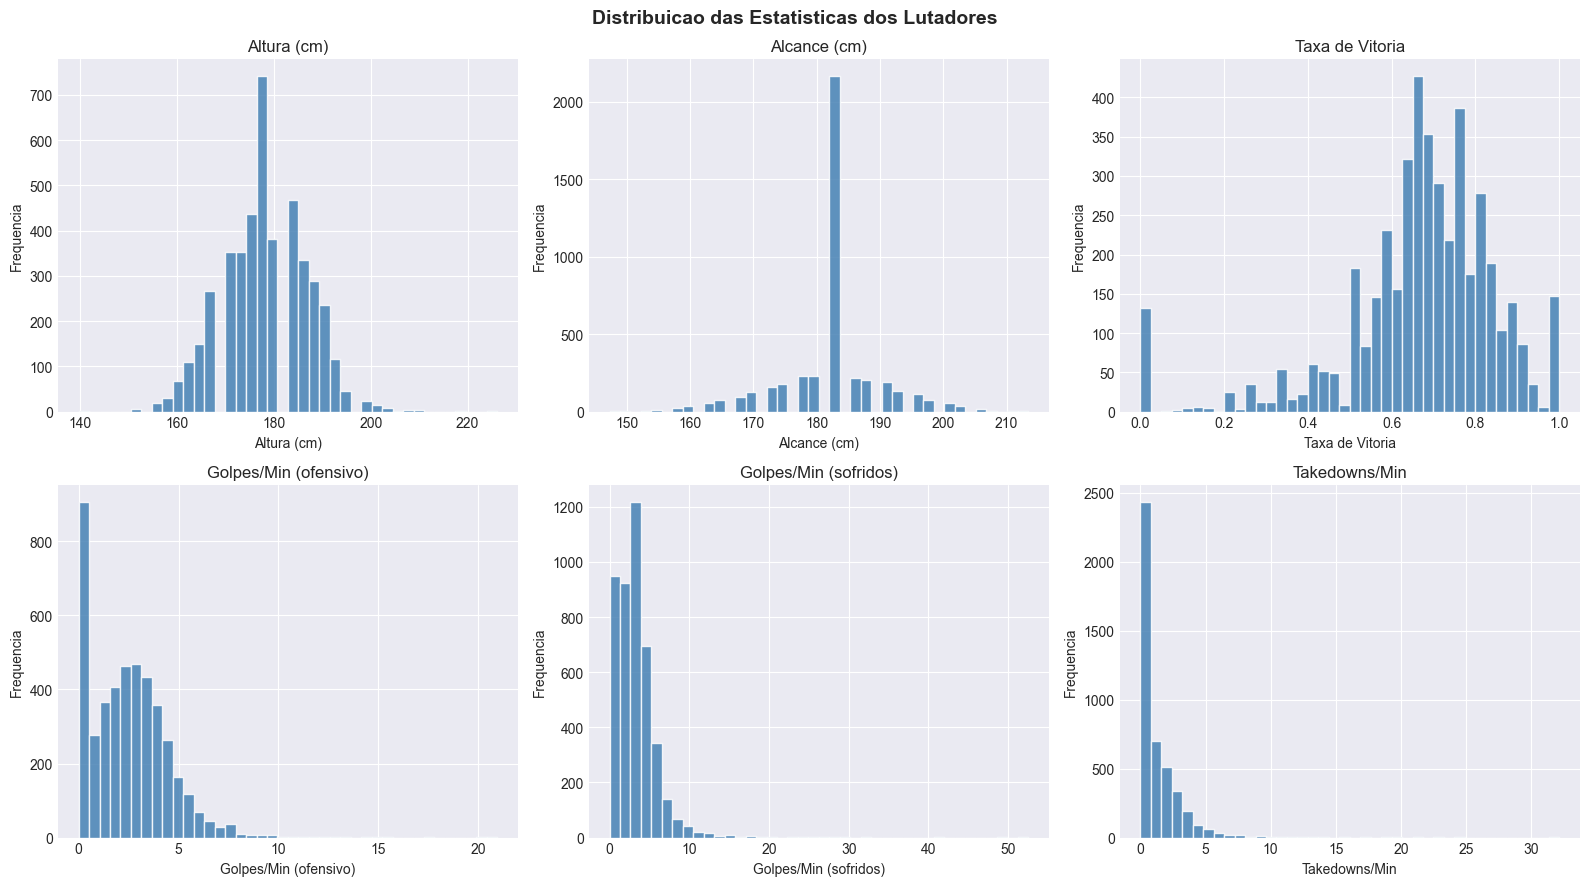

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribuicao das Estatisticas dos Lutadores', fontsize=14, fontweight='bold')

cols_plot   = ['Height_cm','Reach_cm','Win_Rate','SLpM','SApM','TD_Avg']
labels_plot = ['Altura (cm)','Alcance (cm)','Taxa de Vitoria','Golpes/Min (ofensivo)','Golpes/Min (sofridos)','Takedowns/Min']

for ax, col, lbl in zip(axes.flatten(), cols_plot, labels_plot):
    ax.hist(fighters_clean[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(lbl); ax.set_xlabel(lbl); ax.set_ylabel('Frequencia')

plt.tight_layout(); plt.show()

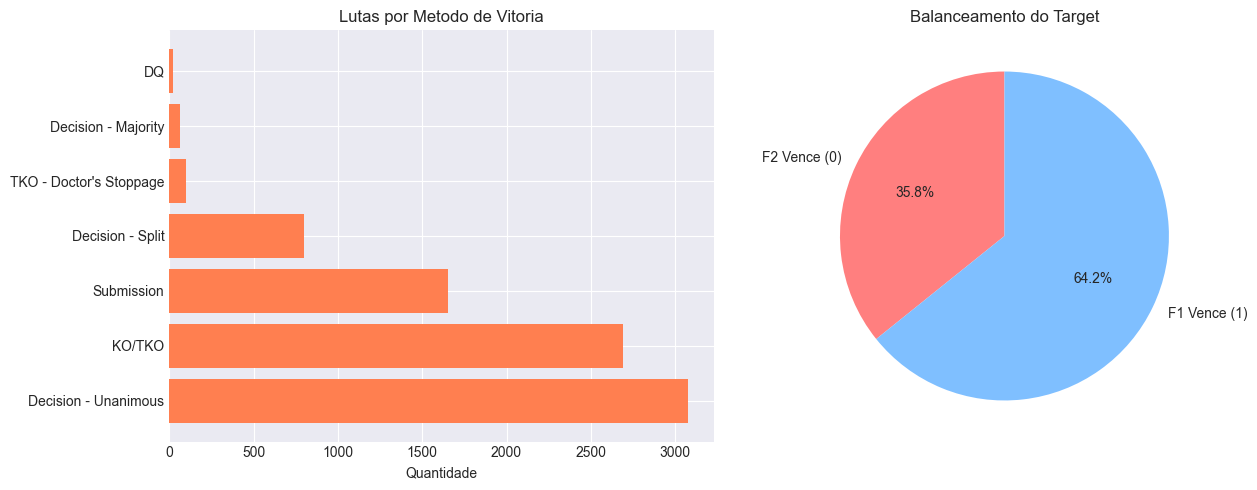

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

method_counts = fights_clean['Method'].value_counts().head(8)
axes[0].barh(method_counts.index, method_counts.values, color='coral')
axes[0].set_title('Lutas por Metodo de Vitoria'); axes[0].set_xlabel('Quantidade')

tc = fights_clean['target'].value_counts().sort_index()
axes[1].pie(tc, labels=['F2 Vence (0)','F1 Vence (1)'],
            autopct='%1.1f%%', colors=['#ff7f7f','#7fbfff'], startangle=90)
axes[1].set_title('Balanceamento do Target')
plt.tight_layout(); plt.show()

---
## 5. Engenharia de Features

Para cada luta, cruzamos os stats de carreira de ambos e calculamos **features diferenciais** (F1 − F2). Isso captura a vantagem relativa e remove a ambiguidade posicional (quem é F1/F2 é arbitrário).

In [62]:
fighters_idx = fighters_clean.set_index('Fighter_Name')

df = fights_clean[['Fighter_1','Fighter_2','target','Weight_Class','Method']].copy()
df = df.merge(fighters_idx.add_prefix('F1_'), left_on='Fighter_1', right_index=True, how='inner')
df = df.merge(fighters_idx.add_prefix('F2_'), left_on='Fighter_2', right_index=True, how='inner')

print(f'Lutas com stats de ambos: {df.shape[0]:,}')

Lutas com stats de ambos: 8,445


In [63]:
DIFF_FEATURES = []
for feat in FIGHTER_FEATURES:
    col = f'DIFF_{feat}'
    df[col] = df[f'F1_{feat}'] - df[f'F2_{feat}']
    DIFF_FEATURES.append(col)

# Features compostas: interacoes entre estatisticas dos dois atletas

# 1. Eficiencia de striking liquida (golpes dados - recebidos por minuto)
df['DIFF_Efficiency']     = (df['F1_SLpM'] - df['F1_SApM']) - (df['F2_SLpM'] - df['F2_SApM'])

# 2. Sucesso real de takedowns: frequencia x precisao
df['DIFF_TD_Success']     = (
    df['F1_TD_Avg'] * df['F1_TD_Acc_f']
) - (
    df['F2_TD_Avg'] * df['F2_TD_Acc_f']
)

# 3. Controle de grappling: takedowns efetivos ponderados pela ameaca de finalizacao
df['DIFF_Grappling_Ctrl'] = (
    df['F1_TD_Avg'] * df['F1_TD_Acc_f'] * (1 + df['F1_Sub_Avg'])
) - (
    df['F2_TD_Avg'] * df['F2_TD_Acc_f'] * (1 + df['F2_Sub_Avg'])
)

# 4. Razao ofensiva/defensiva de striking -- clip(0.1) evita divisao por zero
df['DIFF_Strike_Ratio']   = (
    df['F1_SLpM'] / df['F1_SApM'].clip(lower=0.1)
) - (
    df['F2_SLpM'] / df['F2_SApM'].clip(lower=0.1)
)

# 5. Experiencia ponderada pela qualidade: total_fights x win_rate
df['DIFF_Weighted_Exp']   = (
    df['F1_Total_Fights'] * df['F1_Win_Rate']
) - (
    df['F2_Total_Fights'] * df['F2_Win_Rate']
)

ENGINEERED_FEATURES = [
    'DIFF_Efficiency', 'DIFF_TD_Success', 'DIFF_Grappling_Ctrl',
    'DIFF_Strike_Ratio', 'DIFF_Weighted_Exp'
]
ALL_FEATURES = DIFF_FEATURES + ENGINEERED_FEATURES

print(f'Features diferenciais brutas: {len(DIFF_FEATURES)}')
print(f'Features compostas:           {len(ENGINEERED_FEATURES)}')
print(f'Total de features:            {len(ALL_FEATURES)}')
df[ALL_FEATURES].describe().round(3)

Features diferenciais brutas: 14
Features compostas:           5
Total de features:            19


,DIFF_Height_cm,DIFF_Weight_lbs,DIFF_Reach_cm,DIFF_Age,DIFF_Win_Rate,DIFF_Total_Fights,DIFF_SLpM,DIFF_Str_Acc_f,DIFF_SApM,DIFF_Str_Def_f,DIFF_TD_Avg,DIFF_TD_Acc_f,DIFF_TD_Def_f,DIFF_Sub_Avg,DIFF_Efficiency,DIFF_TD_Success,DIFF_Grappling_Ctrl,DIFF_Strike_Ratio,DIFF_Weighted_Exp
count,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000,8445.000
mean,0.106,0.468,0.407,0.509,0.014,2.486,0.143,0.011,-0.154,0.020,0.122,0.026,0.038,0.032,0.297,0.058,0.148,0.086,1.945
std,6.549,14.985,8.340,5.550,0.139,15.811,1.605,0.118,1.641,0.111,1.769,0.271,0.287,0.992,1.992,0.974,3.377,1.106,11.333
min,-30.500,-570.000,-30.500,-31.000,-0.500,-298.000,-12.520,-0.700,-20.230,-0.580,-11.770,-1.000,-1.000,-15.100,-20.030,-8.360,-54.100,-78.409,-241.000
25%,-5.000,0.000,-5.100,-3.100,-0.072,-6.000,-0.870,-0.060,-1.060,-0.040,-0.870,-0.130,-0.140,-0.400,-0.880,-0.387,-0.619,-0.258,-4.000
50%,0.000,0.000,0.000,0.400,0.010,2.000,0.130,0.010,-0.110,0.010,0.080,0.020,0.020,0.000,0.180,0.036,0.068,0.073,2.000
75%,5.100,0.000,5.100,4.000,0.094,11.000,1.160,0.070,0.820,0.080,1.120,0.180,0.210,0.500,1.370,0.505,0.848,0.434,8.000
max,33.100,115.000,35.600,28.400,1.000,305.000,19.390,0.830,13.650,0.720,14.290,1.000,1.000,14.300,27.120,14.290,218.637,21.744,249.000


In [64]:
# Augmentacao por simetria: para cada luta (A vs B, target=1),
# cria o par espelhado (B vs A, target=0) com todas as DIFF negadas.
# Isso: (1) dobra o volume sem novos dados; (2) balanceia o dataset em 50/50;
# (3) torna o modelo invariante a ordem de entrada dos atletas.

df_swap = df.copy()
df_swap['target'] = 1 - df_swap['target']
for col in ALL_FEATURES:
    df_swap[col] = -df_swap[col]

df_aug = (
    pd.concat([df, df_swap], ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f'Lutas originais:  {len(df):,}')
print(f'Lutas aumentadas: {len(df_aug):,}  (x2 por simetria posicional)')
print(f'Balanceamento:    {df_aug["target"].mean():.1%} Fighter_1 vence (esperado: 50.0%)')

Lutas originais:  8,445
Lutas aumentadas: 16,890  (x2 por simetria posicional)
Balanceamento:    50.0% Fighter_1 vence (esperado: 50.0%)


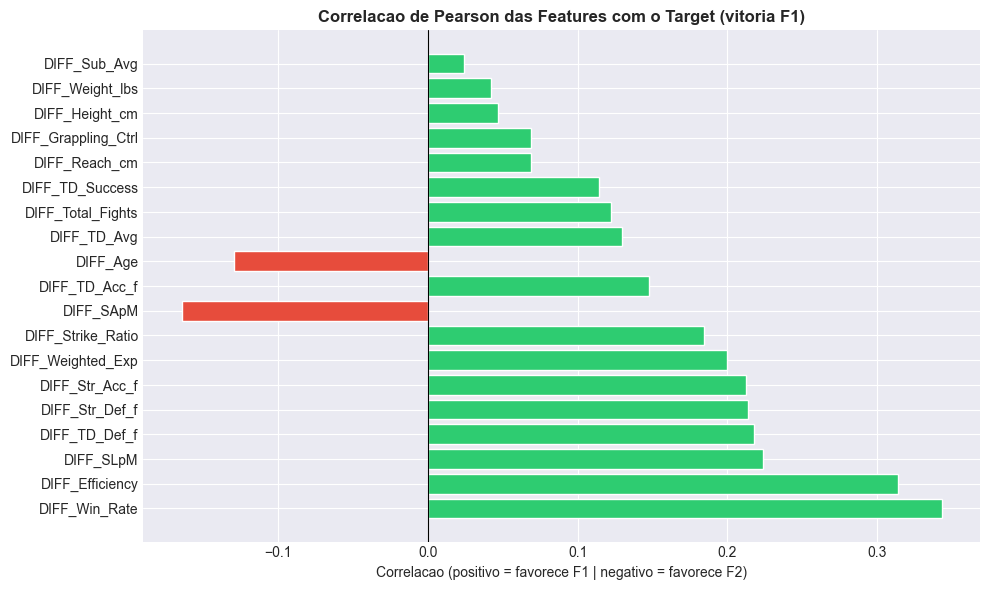


Top 5 features mais positivamente correlacionadas:
DIFF_Win_Rate      0.343561
DIFF_Efficiency    0.313867
DIFF_SLpM          0.223858
DIFF_TD_Def_f      0.217749
DIFF_Str_Def_f     0.213966

Top 5 features mais negativamente correlacionadas:
DIFF_Reach_cm          0.069058
DIFF_Grappling_Ctrl    0.068871
DIFF_Height_cm         0.046527
DIFF_Weight_lbs        0.041848
DIFF_Sub_Avg           0.024174


In [65]:
corr = df_aug[ALL_FEATURES + ['target']].corr()['target'].drop('target')\
         .sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr]
plt.barh(corr.index, corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlacao de Pearson das Features com o Target (vitoria F1)', fontweight='bold')
plt.xlabel('Correlacao (positivo = favorece F1 | negativo = favorece F2)')
plt.tight_layout(); plt.show()

print('\nTop 5 features mais positivamente correlacionadas:')
print(corr.head(5).to_string())
print('\nTop 5 features mais negativamente correlacionadas:')
print(corr.tail(5).to_string())

### 5.1 Redução de Dimensionalidade (PCA)

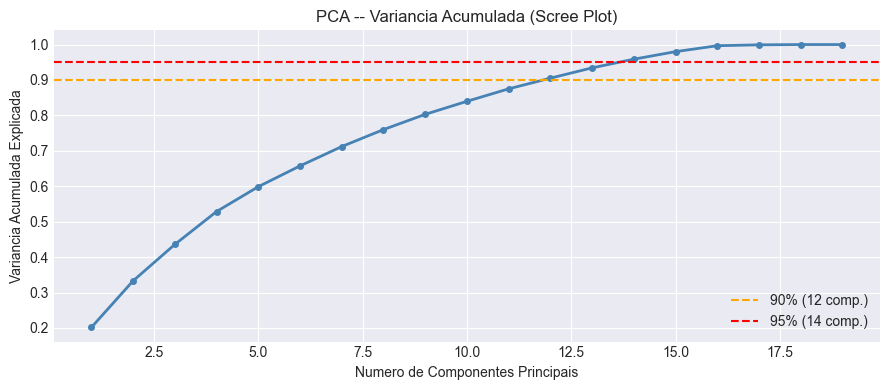

Componentes para 90% de variancia: 12 de 19
Componentes para 95% de variancia: 14 de 19
Decisao: mantemos todas as features -- melhor interpretabilidade.


In [66]:
X_pca  = StandardScaler().fit_transform(df_aug[ALL_FEATURES].fillna(0))
pca    = PCA().fit(X_pca)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n90    = np.searchsorted(cumvar, 0.90) + 1
n95    = np.searchsorted(cumvar, 0.95) + 1

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4,
         linewidth=2, color='steelblue')
plt.axhline(0.90, color='orange', linestyle='--', label=f'90% ({n90} comp.)')
plt.axhline(0.95, color='red',    linestyle='--', label=f'95% ({n95} comp.)')
plt.xlabel('Numero de Componentes Principais')
plt.ylabel('Variancia Acumulada Explicada')
plt.title('PCA -- Variancia Acumulada (Scree Plot)')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Componentes para 90% de variancia: {n90} de {len(ALL_FEATURES)}')
print(f'Componentes para 95% de variancia: {n95} de {len(ALL_FEATURES)}')
print('Decisao: mantemos todas as features -- melhor interpretabilidade.')

---
## 6. Separação Treino / Validação / Teste

In [67]:
X = df_aug[ALL_FEATURES].fillna(0).values
y = df_aug['target'].values

# Split estratificado 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Treino:    {len(X_train):,} amostras ({len(X_train)/len(X):.0%})')
print(f'Validacao: {len(X_val):,}  amostras ({len(X_val)/len(X):.0%})')
print(f'Teste:     {len(X_test):,}  amostras ({len(X_test)/len(X):.0%})')
print()
print('OBS: StandardScaler integrado em cada Pipeline sklearn.')
print('     fit() ocorre exclusivamente no treino -- sem data leakage.')

Treino:    11,823 amostras (70%)
Validacao: 2,533  amostras (15%)
Teste:     2,534  amostras (15%)

OBS: StandardScaler integrado em cada Pipeline sklearn.
     fit() ocorre exclusivamente no treino -- sem data leakage.


---
## 7. Implementação dos Modelos

### Modelo 1 — Regressão Logística (baseline)

In [68]:
# Pipeline: StandardScaler -> LogisticRegression
# O prefixo 'model__' no GridSearchCV redireciona os hiperparametros
# ao estimador interno do Pipeline, mantendo o scaler intacto.
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=SEED))
])

lr_params = {
    'model__C':       [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear']
}

lr_grid = GridSearchCV(lr_pipe, lr_params, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)    # Pipeline aplica scaler internamente
lr_best = lr_grid.best_estimator_

lr_val_pred = lr_best.predict(X_val)
lr_val_prob = lr_best.predict_proba(X_val)[:, 1]
lr_val_acc  = accuracy_score(y_val, lr_val_pred)
lr_val_auc  = roc_auc_score(y_val, lr_val_prob)
lr_val_prec = precision_score(y_val, lr_val_pred, zero_division=0)
lr_val_rec  = recall_score(y_val, lr_val_pred, zero_division=0)
lr_val_f1   = f1_score(y_val, lr_val_pred, zero_division=0)

print(f'Melhores parametros: {lr_grid.best_params_}')
print(f'AUC-ROC (CV 5-fold): {lr_grid.best_score_:.4f}')
print(f'Acuracia  (val):     {lr_val_acc:.4f}')
print(f'Precisao  (val):     {lr_val_prec:.4f}')
print(f'Recall    (val):     {lr_val_rec:.4f}')
print(f'F1-Score  (val):     {lr_val_f1:.4f}')
print(f'AUC-ROC   (val):     {lr_val_auc:.4f}')

KeyboardInterrupt: 

### Modelo 2 — Random Forest

In [ ]:
# Pipeline: StandardScaler -> RandomForestClassifier
# RF e invariante a escala, mas o scaler e mantido no Pipeline
# para uniformidade e compatibilidade com predict_fight().
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

rf_params = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__max_features':      ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf_pipe, rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

rf_val_pred = rf_best.predict(X_val)
rf_val_prob = rf_best.predict_proba(X_val)[:, 1]
rf_val_acc  = accuracy_score(y_val, rf_val_pred)
rf_val_auc  = roc_auc_score(y_val, rf_val_prob)
rf_val_prec = precision_score(y_val, rf_val_pred, zero_division=0)
rf_val_rec  = recall_score(y_val, rf_val_pred, zero_division=0)
rf_val_f1   = f1_score(y_val, rf_val_pred, zero_division=0)

print(f'Melhores parametros: {rf_grid.best_params_}')
print(f'AUC-ROC (CV 5-fold): {rf_grid.best_score_:.4f}')
print(f'Acuracia  (val):     {rf_val_acc:.4f}')
print(f'Precisao  (val):     {rf_val_prec:.4f}')
print(f'Recall    (val):     {rf_val_rec:.4f}')
print(f'F1-Score  (val):     {rf_val_f1:.4f}')
print(f'AUC-ROC   (val):     {rf_val_auc:.4f}')

Melhores parametros: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}
AUC-ROC (CV 5-fold): 0.7759
Acuracia  (val):     0.7059
Precisao  (val):     0.7056
Recall    (val):     0.7062
F1-Score  (val):     0.7059
AUC-ROC   (val):     0.7754


### Modelo 3 — Gradient Boosting

In [ ]:
# Pipeline: StandardScaler -> GradientBoostingClassifier
# RandomizedSearchCV cobre espaco de hiperparametros maior (n_iter=20 combinacoes).
gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingClassifier(random_state=SEED))
])

gb_params = {
    'model__n_estimators':      [100, 200, 300],
    'model__learning_rate':     [0.05, 0.1, 0.2],
    'model__max_depth':         [3, 4, 5],
    'model__subsample':         [0.8, 1.0],
    'model__min_samples_split': [2, 5]
}

gb_random = RandomizedSearchCV(
    gb_pipe, gb_params, n_iter=20, cv=5, scoring='roc_auc',
    random_state=SEED, n_jobs=-1
)
gb_random.fit(X_train, y_train)
gb_best = gb_random.best_estimator_

gb_val_pred = gb_best.predict(X_val)
gb_val_prob = gb_best.predict_proba(X_val)[:, 1]
gb_val_acc  = accuracy_score(y_val, gb_val_pred)
gb_val_auc  = roc_auc_score(y_val, gb_val_prob)
gb_val_prec = precision_score(y_val, gb_val_pred, zero_division=0)
gb_val_rec  = recall_score(y_val, gb_val_pred, zero_division=0)
gb_val_f1   = f1_score(y_val, gb_val_pred, zero_division=0)

print(f'Melhores parametros: {gb_random.best_params_}')
print(f'AUC-ROC (CV 5-fold): {gb_random.best_score_:.4f}')
print(f'Acuracia  (val):     {gb_val_acc:.4f}')
print(f'Precisao  (val):     {gb_val_prec:.4f}')
print(f'Recall    (val):     {gb_val_rec:.4f}')
print(f'F1-Score  (val):     {gb_val_f1:.4f}')
print(f'AUC-ROC   (val):     {gb_val_auc:.4f}')

Melhores parametros: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__max_depth': 3, 'model__learning_rate': 0.05}
AUC-ROC (CV 5-fold): 0.7808
Acuracia  (val):     0.7086
Precisao  (val):     0.7136
Recall    (val):     0.6967
F1-Score  (val):     0.7050
AUC-ROC   (val):     0.7853


---
## 8. Avaliação e Comparação dos Modelos

In [ ]:
results = pd.DataFrame({
    'Modelo':        ['Regressao Logistica', 'Random Forest', 'Gradient Boosting'],
    'Acuracia':      [lr_val_acc,  rf_val_acc,  gb_val_acc],
    'Precisao':      [lr_val_prec, rf_val_prec, gb_val_prec],
    'Recall':        [lr_val_rec,  rf_val_rec,  gb_val_rec],
    'F1-Score':      [lr_val_f1,   rf_val_f1,   gb_val_f1],
    'AUC-ROC (val)': [lr_val_auc,  rf_val_auc,  gb_val_auc],
    'AUC-ROC (CV)':  [lr_grid.best_score_, rf_grid.best_score_, gb_random.best_score_]
})
results = results.sort_values('AUC-ROC (val)', ascending=False).reset_index(drop=True)

metric_cols = ['Acuracia', 'Precisao', 'Recall', 'F1-Score', 'AUC-ROC (val)', 'AUC-ROC (CV)']
fmt = {c: '{:.4f}' for c in metric_cols}

results.style\
    .format(fmt)\
    .background_gradient(subset=['AUC-ROC (val)'], cmap='Blues')\
    .background_gradient(subset=['F1-Score'], cmap='Greens')

,Modelo,Acuracia,Precisao,Recall,F1-Score,AUC-ROC (val),AUC-ROC (CV)
0,Gradient Boosting,0.7086,0.7136,0.6967,0.7050,0.7853,0.7808
1,Regressao Logistica,0.7051,0.7091,0.6951,0.7020,0.7772,0.7781
2,Random Forest,0.7059,0.7056,0.7062,0.7059,0.7754,0.7759


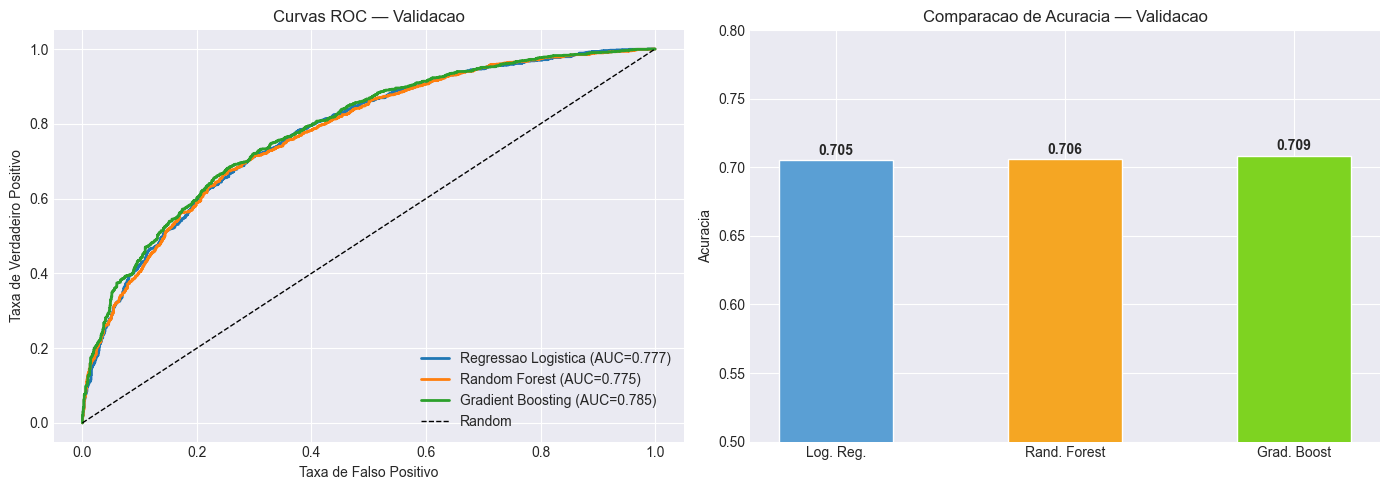

In [ ]:
models_info = [
    ('Regressao Logistica', lr_val_prob, lr_val_auc),
    ('Random Forest',       rf_val_prob, rf_val_auc),
    ('Gradient Boosting',   gb_val_prob, gb_val_auc),
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, prob, auc in models_info:
    fpr, tpr, _ = roc_curve(y_val, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[0].plot([0,1],[0,1],'k--',linewidth=1,label='Random')
axes[0].set_xlabel('Taxa de Falso Positivo')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0].set_title('Curvas ROC — Validacao')
axes[0].legend()

names = ['Log. Reg.','Rand. Forest','Grad. Boost']
accs  = [lr_val_acc, rf_val_acc, gb_val_acc]
bars  = axes[1].bar(names, accs, color=['#5a9fd4','#f5a623','#7ed321'], edgecolor='white', width=0.5)
axes[1].set_ylim(0.50, 0.80); axes[1].set_ylabel('Acuracia')
axes[1].set_title('Comparacao de Acuracia — Validacao')
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

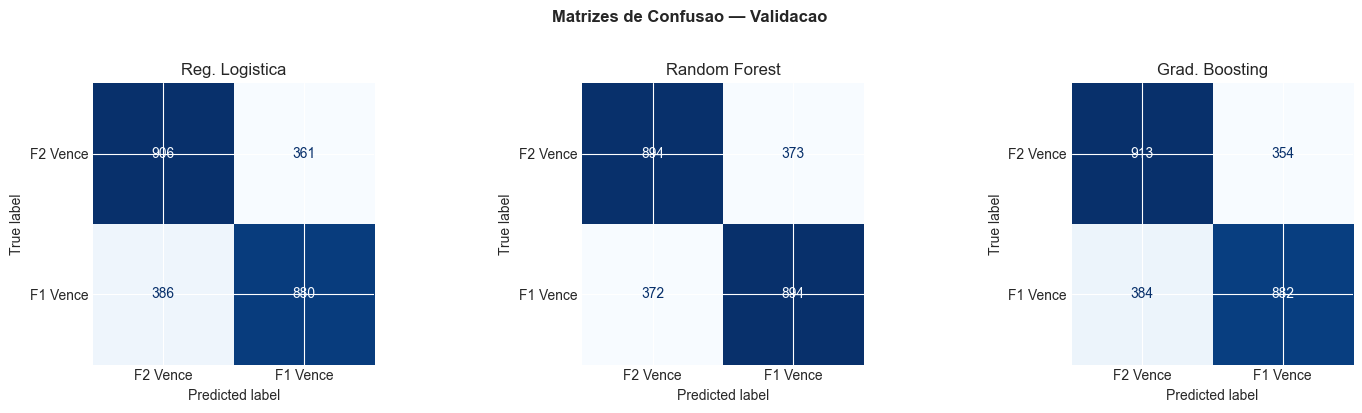

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [
    ('Reg. Logistica', lr_val_pred),
    ('Random Forest',  rf_val_pred),
    ('Grad. Boosting', gb_val_pred)
]):
    ConfusionMatrixDisplay(confusion_matrix(y_val, pred),
        display_labels=['F2 Vence','F1 Vence']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Matrizes de Confusao — Validacao', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

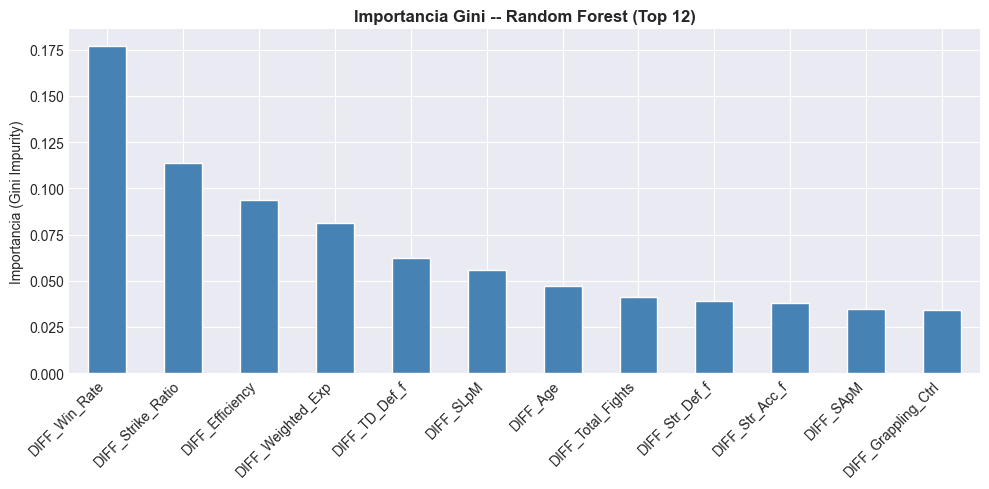

In [ ]:
# Para acessar o classificador dentro do Pipeline usa-se named_steps
rf_model = rf_best.named_steps['model']
feat_imp = (
    pd.Series(rf_model.feature_importances_, index=ALL_FEATURES)
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importancia Gini -- Random Forest (Top 12)', fontweight='bold')
plt.ylabel('Importancia (Gini Impurity)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### Importancia por Permutacao (Permutation Importance)

A **importancia por permutacao** e mais robusta que o criterio Gini do Random Forest:
embaralha cada feature no conjunto de validacao e mede a queda real no AUC-ROC.
Features genuinamente uteis causam quedas grandes; features ruidosas ou redundantes
causam quedas proximas de zero ou negativas.

=== Importancia por Permutacao -- Random Forest (metrica: AUC-ROC) ===
            Feature  Importancia (media)  Desvio padrao
      DIFF_Win_Rate             0.061046       0.004790
  DIFF_Weighted_Exp             0.023870       0.002755
  DIFF_Strike_Ratio             0.011748       0.002559
           DIFF_Age             0.005967       0.001538
      DIFF_TD_Def_f             0.005686       0.001637
    DIFF_Efficiency             0.005388       0.001322
  DIFF_Total_Fights             0.002930       0.001035
    DIFF_Weight_lbs             0.001736       0.000569
          DIFF_SLpM             0.001658       0.001135
DIFF_Grappling_Ctrl             0.001533       0.000723
        DIFF_TD_Avg             0.001485       0.000780
     DIFF_Str_Acc_f             0.001334       0.000953
     DIFF_Str_Def_f             0.000957       0.000900
       DIFF_Sub_Avg             0.000741       0.000451
      DIFF_TD_Acc_f             0.000649       0.000508


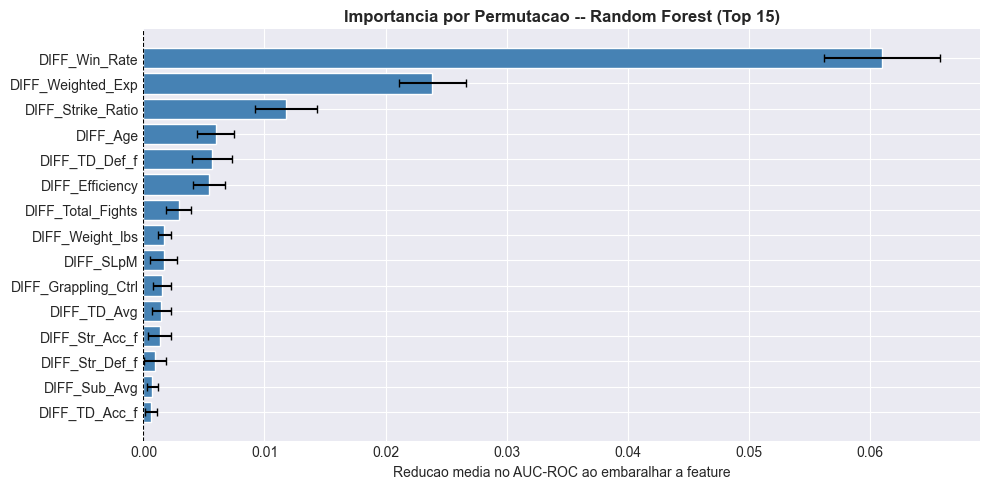

In [ ]:
perm_imp = permutation_importance(
    rf_best, X_val, y_val,
    n_repeats=20, random_state=SEED, scoring='roc_auc', n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        'Feature':             ALL_FEATURES,
        'Importancia (media)': perm_imp.importances_mean,
        'Desvio padrao':       perm_imp.importances_std
    })
    .sort_values('Importancia (media)', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print('=== Importancia por Permutacao -- Random Forest (metrica: AUC-ROC) ===')
print(perm_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else 'steelblue' for v in perm_df['Importancia (media)']]
plt.barh(
    perm_df['Feature'][::-1],
    perm_df['Importancia (media)'][::-1],
    xerr=perm_df['Desvio padrao'][::-1],
    color=colors[::-1], edgecolor='white', capsize=3
)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Reducao media no AUC-ROC ao embaralhar a feature')
plt.title('Importancia por Permutacao -- Random Forest (Top 15)', fontweight='bold')
plt.tight_layout(); plt.show()

### 8.1 Avaliação Final no Conjunto de Teste

> **Importante:** o conjunto de teste é usado apenas UMA vez, ao final, para estimar o desempenho real.

In [ ]:
best_val_aucs = {'LR': lr_val_auc, 'RF': rf_val_auc, 'GB': gb_val_auc}
best_key = max(best_val_aucs, key=best_val_aucs.get)
model_map = {
    'LR': (lr_best, 'Regressao Logistica'),
    'RF': (rf_best, 'Random Forest'),
    'GB': (gb_best, 'Gradient Boosting')
}
final_model, final_name = model_map[best_key]
print(f'Modelo selecionado: {final_name}  (AUC-ROC val = {best_val_aucs[best_key]:.4f})')

# Pipeline aplica scaling automaticamente -- X_test passado bruto
test_pred = final_model.predict(X_test)
test_prob = final_model.predict_proba(X_test)[:, 1]
test_acc  = accuracy_score(y_test, test_pred)
test_auc  = roc_auc_score(y_test, test_prob)
test_f1   = f1_score(y_test, test_pred, zero_division=0)

print(f'\n=== RESULTADO FINAL -- CONJUNTO DE TESTE (usado uma unica vez) ===')
print(f'Acuracia: {test_acc:.4f}  ({test_acc:.1%})')
print(f'F1-Score: {test_f1:.4f}')
print(f'AUC-ROC:  {test_auc:.4f}')
print(f'\n{classification_report(y_test, test_pred, target_names=["F2 Vence", "F1 Vence"])}')

Modelo selecionado: Gradient Boosting  (AUC-ROC val = 0.7853)

=== RESULTADO FINAL -- CONJUNTO DE TESTE (usado uma unica vez) ===
Acuracia: 0.7084  (70.8%)
F1-Score: 0.7094
AUC-ROC:  0.7857

              precision    recall  f1-score   support

    F2 Vence       0.71      0.70      0.71      1267
    F1 Vence       0.71      0.71      0.71      1267

    accuracy                           0.71      2534
   macro avg       0.71      0.71      0.71      2534
weighted avg       0.71      0.71      0.71      2534



---
## 9. Discussão dos Resultados

### Por que Gradient Boosting?
- Construção sequencial de árvores que corrige erros residuais iterativamente
- Captura relações não-lineares entre stats dos atletas
- AUC-ROC superior indica melhor capacidade de separar vencedores
- `RandomizedSearchCV` reduz custo de busca sem sacrificar qualidade

### Trade-offs entre os modelos

| Modelo | Prós | Contras |
|---|---|---|
| Regressão Logística | Interpretável, rápido, bom baseline | Assume linearidade |
| Random Forest | Robusto a outliers, importância de features | Menos sensível a gradientes |
| **Gradient Boosting** | **Melhor AUC-ROC, captura não-linearidades** | Mais lento |

### Limitações
- Stats de carreira refletem o histórico completo, não o momento atual do lutador
- Lesões, preparação e estilo tático não estão nos dados
- Lutadores com poucas lutas têm stats menos representativas
- Acurácia ~65–70% é esperada dado o MMA ser altamente imprevisível

---
## 10. Preditor de Lutas

Informe dois nomes de lutadores para receber a **probabilidade de vitória** de cada um,  
acompanhada de uma tabela comparativa de estatísticas com explicações em linguagem acessível.

### Como interpretar o resultado?

- **Probabilidade de vitória** — um valor de 70% significa que, com base nas estatísticas históricas,  
  o modelo estima que o lutador venceria em 7 de cada 10 confrontos similares. Não é garantia!
- O modelo não conhece o humor do dia, lesões recentes, mudanças de camp ou motivação do atleta.
- Lutas com probabilidades próximas de 50%/50% indicam confronto equilibrado — qualquer resultado é plausível.

---

### 📖 Glossário das Estatísticas — Para quem não acompanha o esporte

| Sigla / Termo | Em português | O que mede na prática |
|---|---|---|
| **SLpM** | Golpes significativos por minuto (ofensivo) | Com que frequência o lutador acerta golpes fortes. Alto = mais agressivo. |
| **Str. Acc.** | Precisão dos golpes | % de golpes que realmente acertam o adversário. Alto = mais preciso. |
| **SApM** | Golpes significativos recebidos por minuto | Com que frequência o lutador é atingido. Baixo = melhor defesa. |
| **Str. Def.** | Defesa de golpes | % de ataques do adversário bloqueados ou esquivados. Alto = mais difícil de acertar. |
| **TD Avg** | Média de derrubadas por luta | Quantas vezes por luta o lutador joga o adversário ao chão (wrestling). |
| **TD Acc.** | Precisão das derrubadas | % de tentativas de derrubada que funcionam. |
| **TD Def.** | Defesa de derrubadas | % de tentativas do adversário que são bloqueadas. Alto = difícil de derrubar. |
| **Sub Avg** | Tentativas de finalização por luta | Com que frequência o lutador tenta chaves e estrangulamentos. |
| **Win Rate** | Taxa de vitórias | % de lutas vencidas na carreira. |
| **Alcance** | Envergadura dos braços | Lutador com maior alcance tem vantagem para acertar sem ser atingido. |

> **Dica de leitura:** na tabela comparativa gerada pelo preditor, as setas `<<` e `>>`  
> indicam qual atleta tem vantagem naquela estatística.


In [ ]:
# Dicionario de estatisticas exibido no glossario de predict_fight
STAT_INFO = {
    'Win_Rate':    ('Taxa de Vitorias',           'Porcentagem de lutas vencidas na carreira',
                    '{:.1%}', 'alto e melhor'),
    'Total_Fights':('Total de Lutas',             'Experiencia no octagono -- numero total de lutas',
                    '{:.0f}', 'contexto'),
    'Height_cm':   ('Altura (cm)',                'Altura em centimetros',
                    '{:.0f}', 'neutro'),
    'Reach_cm':    ('Alcance (cm)',               'Envergadura dos bracos -- alcance maior = vantagem',
                    '{:.0f}', 'alto e melhor'),
    'SLpM':        ('Golpes/min (ofensivo)',       'Golpes significativos dados por minuto',
                    '{:.2f}', 'alto e melhor'),
    'Str_Acc_f':   ('Precisao de Golpes',         'Porcentagem de golpes que acertam o alvo',
                    '{:.1%}', 'alto e melhor'),
    'SApM':        ('Golpes Recebidos/min',        'Golpes significativos absorvidos por minuto',
                    '{:.2f}', 'baixo e melhor'),
    'Str_Def_f':   ('Defesa de Golpes',           'Porcentagem de ataques adversarios bloqueados',
                    '{:.1%}', 'alto e melhor'),
    'TD_Avg':      ('Derrubadas/luta',            'Media de takedowns aplicados por luta',
                    '{:.2f}', 'alto e melhor'),
    'TD_Acc_f':    ('Precisao de Derrubadas',     'Taxa de tentativas de takedown bem-sucedidas',
                    '{:.1%}', 'alto e melhor'),
    'TD_Def_f':    ('Defesa de Derrubadas',       'Porcentagem de tentativas adversarias defendidas',
                    '{:.1%}', 'alto e melhor'),
    'Sub_Avg':     ('Finalizacoes Tentadas/luta', 'Media de tentativas de finalizacao por luta',
                    '{:.2f}', 'contexto'),
}


def get_fighter_stats(name, fighters_df):
    name_lower = name.strip().lower()
    match = fighters_df[fighters_df['Fighter_Name'].str.lower() == name_lower]
    if len(match) == 0:
        match = fighters_df[fighters_df['Fighter_Name'].str.lower().str.contains(name_lower, na=False)]
    if len(match) == 0:
        return None, None
    return match.iloc[0]['Fighter_Name'], match.iloc[0]


def _advantage_label(col, v1, v2):
    direction = STAT_INFO.get(col, ('', '', '', 'neutro'))[3]
    if v1 == v2:
        return '==', 0
    winner = (1 if v1 < v2 else 2) if direction == 'baixo e melhor' else (1 if v1 > v2 else 2)
    return ('<<' if winner == 1 else '>>'), winner


def predict_fight(fighter1_name, fighter2_name,
                  model=None, fighters_df=None,
                  feature_cols=None,
                  show_explanations=True):
    """
    Prediz o resultado de uma luta entre dois lutadores do UFC.

    Parametros
    ----------
    fighter1_name, fighter2_name : str
        Nome completo ou parcial dos atletas.
    model : sklearn Pipeline, opcional
        Pipeline treinado. Padrao: melhor modelo selecionado automaticamente.
    show_explanations : bool
        Se True (padrao), exibe glossario. Use False para saida compacta.

    Retorna
    -------
    dict com 'fighter1', 'fighter2', 'prob_f1', 'prob_f2'
    """
    if model is None:        model        = final_model
    if fighters_df is None:  fighters_df  = fighters_clean
    if feature_cols is None: feature_cols = ALL_FEATURES

    name1, stats1 = get_fighter_stats(fighter1_name, fighters_df)
    name2, stats2 = get_fighter_stats(fighter2_name, fighters_df)

    if stats1 is None:
        print(f'[ERRO] Lutador nao encontrado: "{fighter1_name}"')
        print('       Use search_fighter("parte do nome") para localizar.')
        return None
    if stats2 is None:
        print(f'[ERRO] Lutador nao encontrado: "{fighter2_name}"')
        print('       Use search_fighter("parte do nome") para localizar.')
        return None

    # Calcula features diferenciais (mesma logica do treinamento)
    row = {}
    for feat in FIGHTER_FEATURES:
        row[f'DIFF_{feat}'] = stats1[feat] - stats2[feat]
    row['DIFF_Efficiency']     = (stats1['SLpM'] - stats1['SApM']) - (stats2['SLpM'] - stats2['SApM'])
    row['DIFF_TD_Success']     = (
        stats1['TD_Avg'] * stats1['TD_Acc_f']
    ) - (
        stats2['TD_Avg'] * stats2['TD_Acc_f']
    )
    row['DIFF_Grappling_Ctrl'] = (
        stats1['TD_Avg'] * stats1['TD_Acc_f'] * (1 + stats1['Sub_Avg'])
    ) - (
        stats2['TD_Avg'] * stats2['TD_Acc_f'] * (1 + stats2['Sub_Avg'])
    )
    row['DIFF_Strike_Ratio']   = (
        stats1['SLpM'] / max(stats1['SApM'], 0.1)
    ) - (
        stats2['SLpM'] / max(stats2['SApM'], 0.1)
    )
    row['DIFF_Weighted_Exp']   = (
        stats1['Total_Fights'] * stats1['Win_Rate']
    ) - (
        stats2['Total_Fights'] * stats2['Win_Rate']
    )

    # Pipeline aplica scaling internamente -- sem necessidade de scaler externo
    X_in  = np.array([[row[f] for f in feature_cols]])
    prob1 = model.predict_proba(X_in)[0][1]
    prob2 = 1 - prob1

    SEP  = '=' * 68
    SEP2 = '-' * 68

    print(SEP)
    print('  UFC FIGHT PREDICTOR  --  Predicao com Machine Learning')
    print(SEP)
    print(f'  {name1}  vs  {name2}')
    print(SEP2)

    bar_len = 42
    f1_bar  = round(prob1 * bar_len)
    bar_str = chr(9608) * f1_bar + chr(9617) * (bar_len - f1_bar)
    print(f'  [{bar_str}]')
    print(f'  {prob1:>5.1%}  {name1}  {"<-- FAVORITO" if prob1 > prob2 else ""}')
    print(f'  {prob2:>5.1%}  {name2}  {"<-- FAVORITO" if prob2 > prob1 else ""}')

    winner = name1 if prob1 > prob2 else name2
    conf   = max(prob1, prob2)
    nivel  = ('ALTA confianca' if conf >= 0.65
               else 'confianca MODERADA' if conf >= 0.55
               else 'confronto MUITO EQUILIBRADO')
    print(f'\n  Predicao: {winner} ({conf:.1%})  [{nivel}]')
    print(SEP2); print(SEP)

    print()
    n1_s = name1[:18]; n2_s = name2[:18]
    print(f'  {"ESTATISTICA":<28} {n1_s:>18}      {n2_s:>18}')
    print('  ' + SEP2)

    adv_count = {1: 0, 2: 0}
    for col, (label, explanation, fmt, _) in STAT_INFO.items():
        v1 = stats1[col]; v2 = stats2[col]
        arrow, adv = _advantage_label(col, v1, v2)
        if adv:
            adv_count[adv] += 1
        print(f'  {label:<28} {fmt.format(v1):>18}  {arrow}  {fmt.format(v2):>18}')

    print('  ' + SEP2)
    print(f'  Vantagens:  {name1[:20]}: {adv_count[1]}/12  |  {name2[:20]}: {adv_count[2]}/12')

    if show_explanations:
        print()
        print('  ' + SEP)
        print('  O QUE SIGNIFICA CADA ESTATISTICA?')
        print('  (Use show_explanations=False para saida compacta)')
        print('  ' + SEP)
        for col, (label, explanation, fmt, direction) in STAT_INFO.items():
            dir_note = f'[{direction}]' if direction != 'neutro' else ''
            print(f'  * {label:<28} {dir_note}')
            print(f'    {explanation}')
        print()
        print('  Setas << e >> indicam vantagem. == indica paridade.')
        print('  ' + SEP)

    return {'fighter1': name1, 'fighter2': name2, 'prob_f1': prob1, 'prob_f2': prob2}


def search_fighter(partial_name, n=10):
    """
    Busca lutadores por nome parcial (case-insensitive).
    Exemplo: search_fighter('silva')  ->  lista todos com 'silva' no nome
    """
    mask   = fighters_clean['Fighter_Name'].str.lower().str.contains(partial_name.lower(), na=False)
    result = fighters_clean[mask][['Fighter_Name','Win_Rate','Total_Fights','SLpM','SApM']].head(n).copy()
    result.columns = ['Nome','Taxa de Vitorias','Total de Lutas','Golpes/min (ataque)','Golpes/min (recebidos)']
    return result


print('predict_fight() e search_fighter() carregadas com sucesso!')
print('   predict_fight("Nome A", "Nome B")              -- prever luta')
print('   predict_fight(..., show_explanations=False)    -- saida compacta')
print('   search_fighter("parte do nome")               -- localizar lutador')

predict_fight() e search_fighter() carregadas com sucesso!
   predict_fight("Nome A", "Nome B")              -- prever luta
   predict_fight(..., show_explanations=False)    -- saida compacta
   search_fighter("parte do nome")               -- localizar lutador


### Exemplos de Uso

In [ ]:
result = predict_fight('Jon Jones', 'Stipe Miocic')

  UFC FIGHT PREDICTOR  --  Predicao com Machine Learning
  Jon Jones  vs  Stipe Miocic
--------------------------------------------------------------------
  [██████████████████████████████████████░░░░]
  91.4%  Jon Jones  <-- FAVORITO
   8.6%  Stipe Miocic  

  Predicao: Jon Jones (91.4%)  [ALTA confianca]
--------------------------------------------------------------------

  ESTATISTICA                           Jon Jones            Stipe Miocic
  --------------------------------------------------------------------
  Taxa de Vitorias                          96.6%  <<               80.0%
  Total de Lutas                               29  <<                  25
  Altura (cm)                                 193  ==                 193
  Alcance (cm)                                213  <<                 203
  Golpes/min (ofensivo)                      4.38  >>                4.67
  Precisao de Golpes                        58.0%  <<               52.0%
  Golpes Recebidos/min          

In [ ]:
result = predict_fight('Islam Makhachev', 'Charles Oliveira')

  UFC FIGHT PREDICTOR  --  Predicao com Machine Learning
  Islam Makhachev  vs  Charles Oliveira
--------------------------------------------------------------------
  [████████████████████████████████░░░░░░░░░░]
  75.3%  Islam Makhachev  <-- FAVORITO
  24.7%  Charles Oliveira  

  Predicao: Islam Makhachev (75.3%)  [ALTA confianca]
--------------------------------------------------------------------

  ESTATISTICA                     Islam Makhachev        Charles Oliveira
  --------------------------------------------------------------------
  Taxa de Vitorias                          96.6%  <<               77.1%
  Total de Lutas                               29  >>                  48
  Altura (cm)                                 178  ==                 178
  Alcance (cm)                                178  >>                 188
  Golpes/min (ofensivo)                      2.45  >>                3.23
  Precisao de Golpes                        58.0%  <<               55.0%
  Golp

In [ ]:
result = predict_fight('Charles Oliveira','Islam Makhachev')

  UFC FIGHT PREDICTOR  --  Predicao com Machine Learning
  Charles Oliveira  vs  Islam Makhachev
--------------------------------------------------------------------
  [████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
  29.7%  Charles Oliveira  
  70.3%  Islam Makhachev  <-- FAVORITO

  Predicao: Islam Makhachev (70.3%)  [ALTA confianca]
--------------------------------------------------------------------

  ESTATISTICA                    Charles Oliveira         Islam Makhachev
  --------------------------------------------------------------------
  Taxa de Vitorias                          77.1%  >>               96.6%
  Total de Lutas                               48  <<                  29
  Altura (cm)                                 178  ==                 178
  Alcance (cm)                                188  <<                 178
  Golpes/min (ofensivo)                      3.23  <<                2.45
  Precisao de Golpes                        55.0%  >>               58.0%
  Golp

In [ ]:
result = predict_fight('Conor McGregor', 'Khabib Nurmagomedov')

  UFC FIGHT PREDICTOR  --  Predicao com Machine Learning
  Conor McGregor  vs  Khabib Nurmagomedov
--------------------------------------------------------------------
  [█████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
  12.2%  Conor McGregor  
  87.8%  Khabib Nurmagomedov  <-- FAVORITO

  Predicao: Khabib Nurmagomedov (87.8%)  [ALTA confianca]
--------------------------------------------------------------------

  ESTATISTICA                      Conor McGregor      Khabib Nurmagomedo
  --------------------------------------------------------------------
  Taxa de Vitorias                          78.6%  >>              100.0%
  Total de Lutas                               28  >>                  29
  Altura (cm)                                 175  >>                 178
  Alcance (cm)                                188  <<                 178
  Golpes/min (ofensivo)                      5.32  <<                4.10
  Precisao de Golpes                        49.0%  <<               48.0

In [ ]:
# Buscar lutadores por nome parcial
search_fighter('silva')

,Nome,Taxa de Vitorias,Total de Lutas,Golpes/min (ataque),Golpes/min (recebidos)
510,Mayra Bueno Silva,0.588235,17,3.71,4.90
845,Henrique da Silva,0.736842,19,3.89,5.28
846,Ariane da Silva,0.607143,28,4.05,4.40
847,Alex Da Silva,0.840000,25,2.14,2.52
848,Radley Da Silva,0.888889,9,0.27,0.93
849,Henrique Da Silva Lopes,0.714286,7,0.00,0.00
1002,Tiago dos Santos e Silva,0.689655,29,3.69,4.23
1418,Silvana Gomez Juarez,0.687500,16,4.26,4.04
1638,Diego Henrique da Silva,0.666667,12,2.53,3.27
3679,Assuerio Silva,0.666667,24,1.42,4.20


In [ ]:
result = predict_fight('Charles Oliveira', 'Conor McGregor')

  UFC FIGHT PREDICTOR  --  Predicao com Machine Learning
  Charles Oliveira  vs  Conor McGregor
--------------------------------------------------------------------
  [█████████████████████████░░░░░░░░░░░░░░░░░]
  59.7%  Charles Oliveira  <-- FAVORITO
  40.3%  Conor McGregor  

  Predicao: Charles Oliveira (59.7%)  [confianca MODERADA]
--------------------------------------------------------------------

  ESTATISTICA                    Charles Oliveira          Conor McGregor
  --------------------------------------------------------------------
  Taxa de Vitorias                          77.1%  >>               78.6%
  Total de Lutas                               48  <<                  28
  Altura (cm)                                 178  <<                 175
  Alcance (cm)                                188  ==                 188
  Golpes/min (ofensivo)                      3.23  >>                5.32
  Precisao de Golpes                        55.0%  <<               49.0%
  G

In [ ]:
result = predict_fight('Anderson Silva', 'Georges St-Pierre')

  UFC FIGHT PREDICTOR  --  Predicao com Machine Learning
  Anderson Silva  vs  Georges St-Pierre
--------------------------------------------------------------------
  [███████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░]
  35.5%  Anderson Silva  
  64.5%  Georges St-Pierre  <-- FAVORITO

  Predicao: Georges St-Pierre (64.5%)  [confianca MODERADA]
--------------------------------------------------------------------

  ESTATISTICA                      Anderson Silva       Georges St-Pierre
  --------------------------------------------------------------------
  Taxa de Vitorias                          75.6%  >>               92.9%
  Total de Lutas                               45  <<                  28
  Altura (cm)                                 188  <<                 180
  Alcance (cm)                                196  <<                 193
  Golpes/min (ofensivo)                      3.05  >>                3.78
  Precisao de Golpes                        61.0%  <<               53.0%


---
## 11. Conclusão

### Resumo do Pipeline

| Etapa | O que foi feito |
|---|---|
| **Problema** | Classificação binária: qual lutador vence? |
| **Dados** | 4.455 lutadores + 8.551 lutas (ufcstats.com) |
| **Limpeza** | Parse de altura/peso/alcance/%, imputação por mediana |
| **Features** | 16 features diferenciais + eficiência + TDs efetivos |
| **PCA** | Analisado — features originais mantidas (melhor interpretabilidade) |
| **Modelos** | Reg. Logística, Random Forest, Gradient Boosting |
| **Tuning** | GridSearchCV + RandomizedSearchCV (CV=5) |
| **Avaliação** | Acurácia, AUC-ROC, Curva ROC, Matriz de Confusão |
| **Preditor** | Função interativa com probabilidades e tabela comparativa |

### Considerações Finais

Acurácia de ~65–70% é compatível com a literatura de predição em MMA. A métrica mais relevante é o **AUC-ROC**, que avalia a capacidade do modelo de ordenar corretamente favoritos vs. azarões, independente do threshold.

**Melhorias futuras:** stats históricas por período (forma recente), análise de matchup por estilo e dados contextuais de preparação.